Problem Statement:


Walmart operates multiple stores and departments across different locations. Weekly sales are influenced by various factors such as store characteristics, economic conditions, fuel prices, holidays, and promotional markdowns. The objective of this project is to build a machine learning model capable of accurately forecasting weekly sales using historical sales data and external business factors. Accurate demand forecasting helps optimize inventory management, staffing, promotions, and overall business planning.



# imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)



Data Loading

In [ ]:
s=pd.read_csv(r"/content/stores.csv")
train=pd.read_csv(r"/content/train.csv")
test=pd.read_csv(r"/content/test.csv")
f=pd.read_csv(r"/content/features.csv")

DATA overview

In [ ]:
print("STORES ")
print(s.head())
print(" train")
print(train.head())
print("features")
print(f.head())


STORES 
   Store Type    Size
0      1    A  151315
1      2    A  202307
2      3    B   37392
3      4    A  205863
4      5    B   34875
 train
   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  2010-02-05      24924.50      False
1      1     1  2010-02-12      46039.49       True
2      1     1  2010-02-19      41595.55      False
3      1     1  2010-02-26      19403.54      False
4      1     1  2010-03-05      21827.90      False
features
   Store        Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
0      1  2010-02-05        42.31       2.572        NaN        NaN   
1      1  2010-02-12        38.51       2.548        NaN        NaN   
2      1  2010-02-19        39.93       2.514        NaN        NaN   
3      1  2010-02-26        46.63       2.561        NaN        NaN   
4      1  2010-03-05        46.50       2.625        NaN        NaN   

   MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment  IsHoliday  
0        NaN        NaN        

Merging all the data


WHY?

Weekly sales are not influenced by historical sales alone. External factors such as promotions, CPI, unemployment, fuel prices, store type, and store size also impact demand. Therefore, all datasets were merged to create a unified dataset containing both sales information and business-related predictors.

In [ ]:
train_merged = pd.merge(train,f,on=["Store", "Date", "IsHoliday"],how="left")

In [ ]:
final_data = pd.merge(train_merged,s,on="Store",how="left")

In [ ]:
final_data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


Null values checking

In [ ]:
final_data.isnull().sum().sort_values(ascending=False)

,0
MarkDown2,310322
MarkDown4,286603
MarkDown3,284479
MarkDown1,270889
MarkDown5,270138
Store,0
Date,0
Dept,0
Fuel_Price,0
Temperature,0


Filling missing values

In [ ]:
markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4', 'MarkDown5']

final_data[markdown_cols] = final_data[markdown_cols].fillna(0)

In [ ]:
final_data.isnull().sum().sort_values(ascending=False)

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,0
MarkDown2,0
MarkDown3,0


In [ ]:
final_data["Date"] = pd.to_datetime(final_data["Date"])

In [ ]:
final_data["Year"] = final_data["Date"].dt.year
final_data["Month"] = final_data["Date"].dt.month
final_data["Week"] = final_data["Date"].dt.isocalendar().week
final_data["Quarter"] = final_data["Date"].dt.quarter

In [ ]:
print(final_data.shape)

print("\nMissing Values:")
print(final_data.isnull().sum().sort_values(ascending=False))

print("\nData Types:")
print(final_data.dtypes)

(421570, 20)

Missing Values:
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
Year            0
Month           0
Week            0
Quarter         0
dtype: int64

Data Types:
Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday                 bool
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
Type                    object
Size                     int64
Year                     int32
Month                    int32
Week                    UI

In [ ]:
final_data = pd.get_dummies(
    final_data,
    columns=['Type'],
    drop_first=True
)

In [ ]:
final_data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,MarkDown5,CPI,Unemployment,Size,Year,Month,Week,Quarter,Type_B,Type_C
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,...,0.0,211.096358,8.106,151315,2010,2,5,1,False,False
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,...,0.0,211.242170,8.106,151315,2010,2,6,1,False,False
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,...,0.0,211.289143,8.106,151315,2010,2,7,1,False,False
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,...,0.0,211.319643,8.106,151315,2010,2,8,1,False,False
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,...,0.0,211.350143,8.106,151315,2010,3,9,1,False,False


The describe() function was used to understand the statistical properties of the dataset before model building.


In [ ]:
final_data.describe()

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size,Year,Month,Week,Quarter
count,421570.000000,421570.000000,421570,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.0,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375104,15981.258123,60.090059,3.361027,2590.074819,879.974298,468.087665,1083.132268,1662.772385,171.201947,7.960289,136727.915739,2010.968591,6.449510,25.826762,2.482767
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,-2.060000,2.472000,0.000000,-265.760000,-29.100000,0.000000,0.000000,126.064000,3.879000,34875.000000,2010.000000,1.000000,1.0,1.000000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,46.680000,2.933000,0.000000,0.000000,0.000000,0.000000,0.000000,132.022667,6.891000,93638.000000,2010.000000,4.000000,14.0,2.000000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,62.090000,3.452000,0.000000,0.000000,0.000000,0.000000,0.000000,182.318780,7.866000,140167.000000,2011.000000,6.000000,26.0,2.000000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,74.280000,3.738000,2809.050000,2.200000,4.540000,425.290000,2168.040000,212.416993,8.572000,202505.000000,2012.000000,9.000000,38.0,3.000000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000,2012.000000,12.000000,52.0,4.000000
std,12.785297,30.492054,NaN,22711.183519,18.447931,0.458515,6052.385934,5084.538801,5528.873453,3894.529945,4207.629321,39.159276,1.863296,60980.583328,0.796876,3.243217,14.151887,1.071341


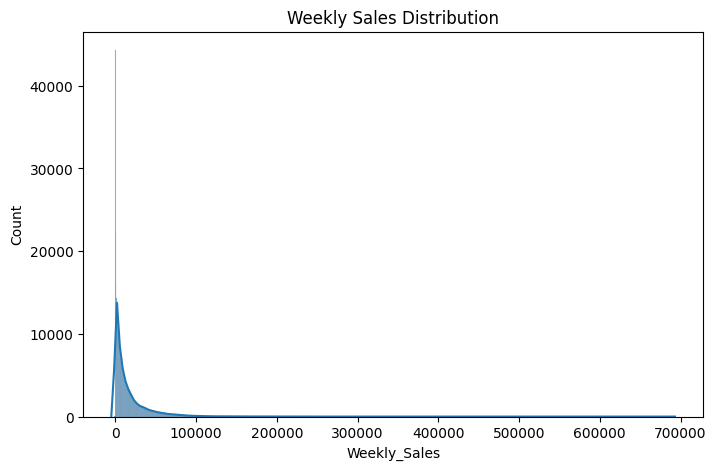

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(final_data["Weekly_Sales"], kde=True)
plt.title("Weekly Sales Distribution")
plt.show()

Weekly sales are heavily right-skewed with several extreme values.

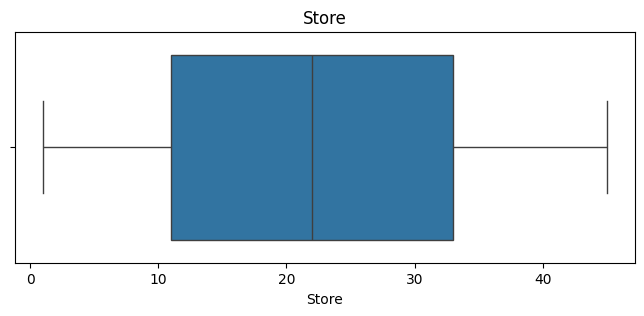

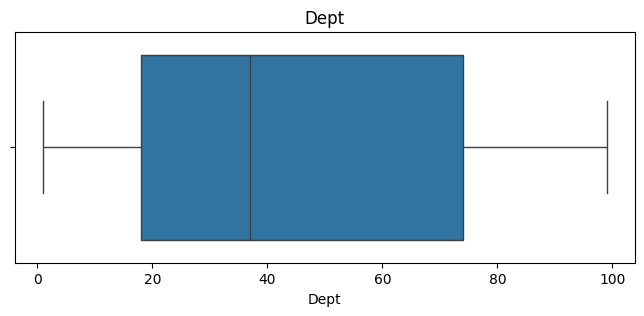

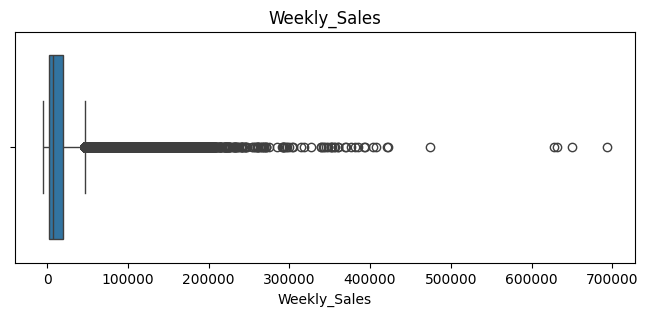

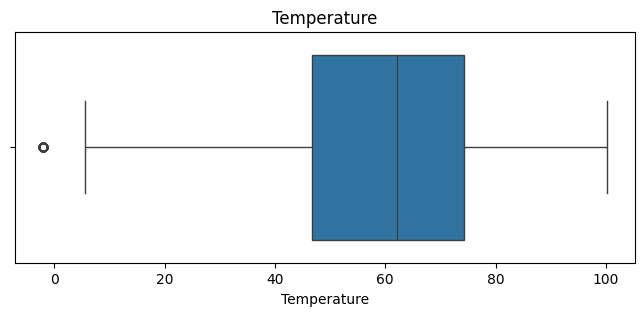

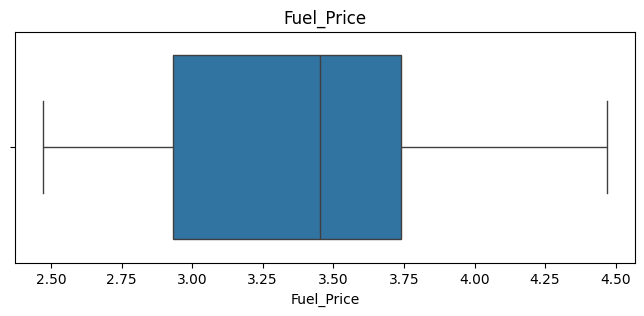

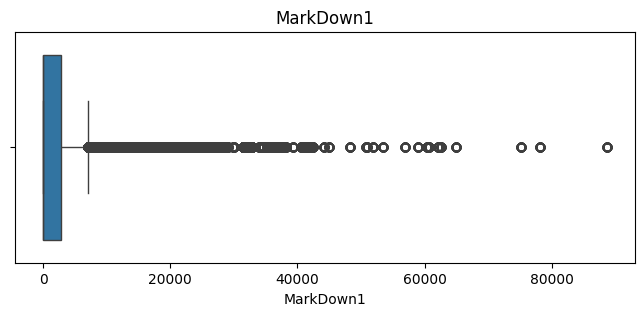

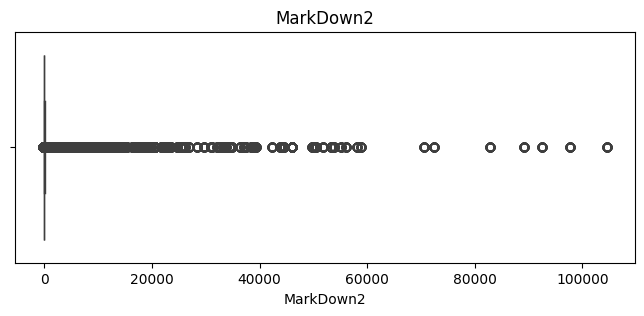

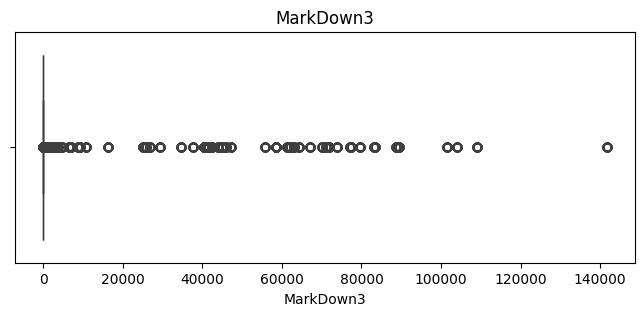

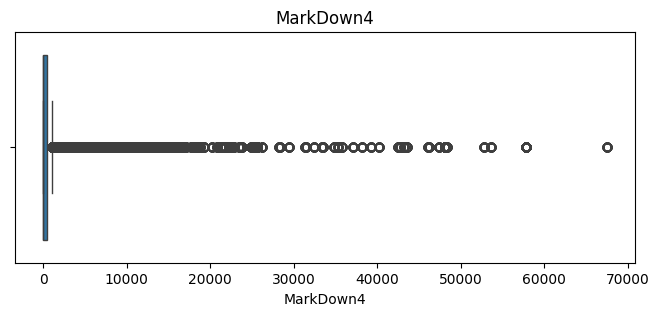

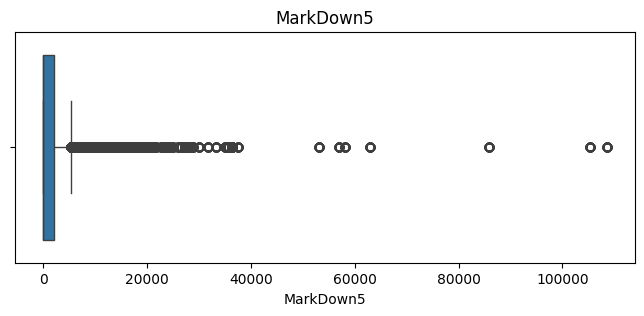

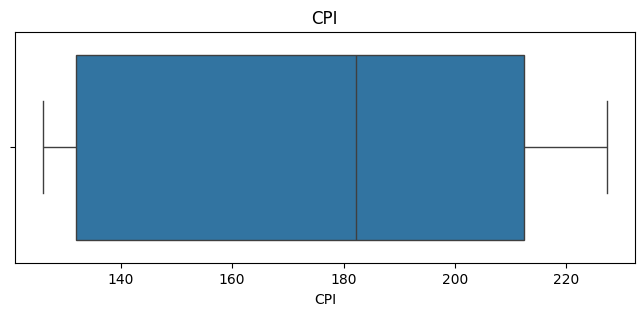

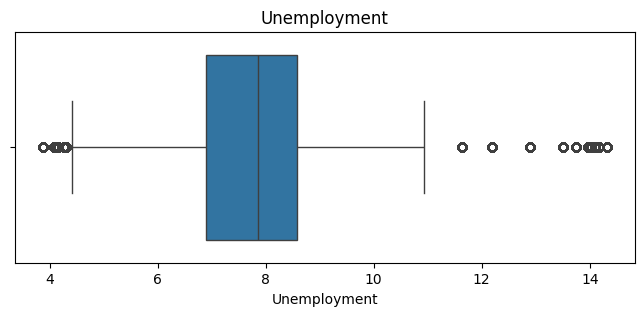

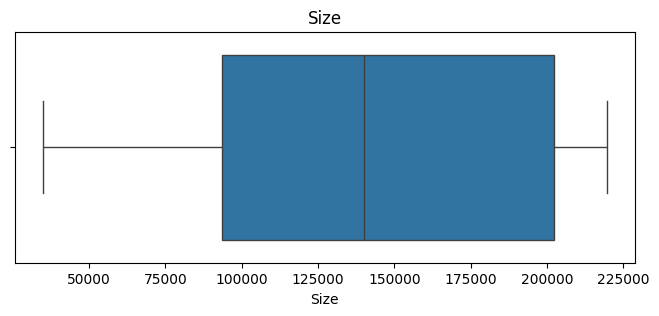

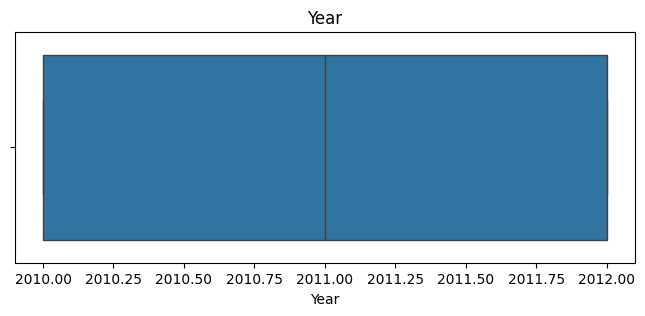

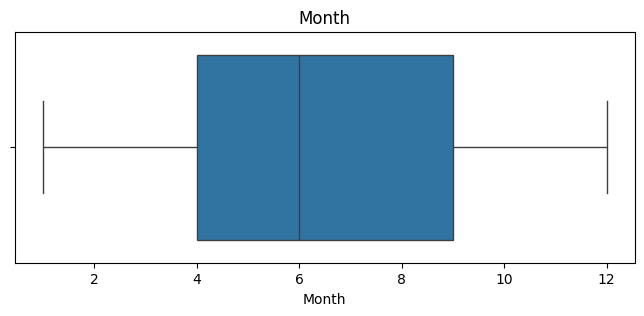

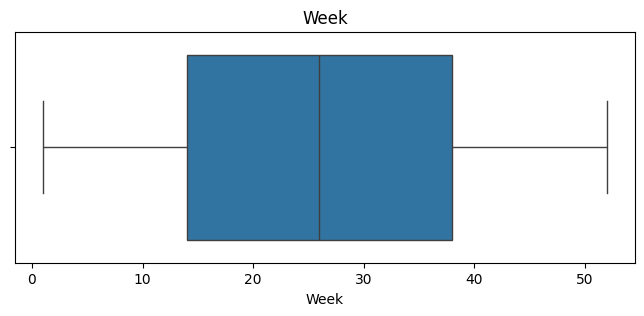

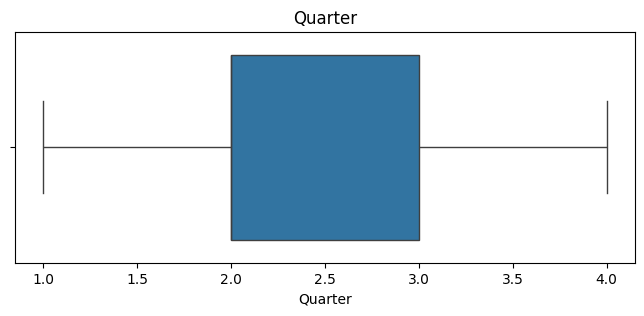

In [ ]:
num_cols = final_data.select_dtypes(include='number').columns

for col in num_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=final_data[col])
    plt.title(col)
    plt.show()

Outlier analysis helps identify unusual observations that may influence model performance. In retail forecasting, many outliers correspond to real business events such as holiday sales and promotional campaigns rather than data errors. Therefore, these values were analyzed rather than immediately removed.

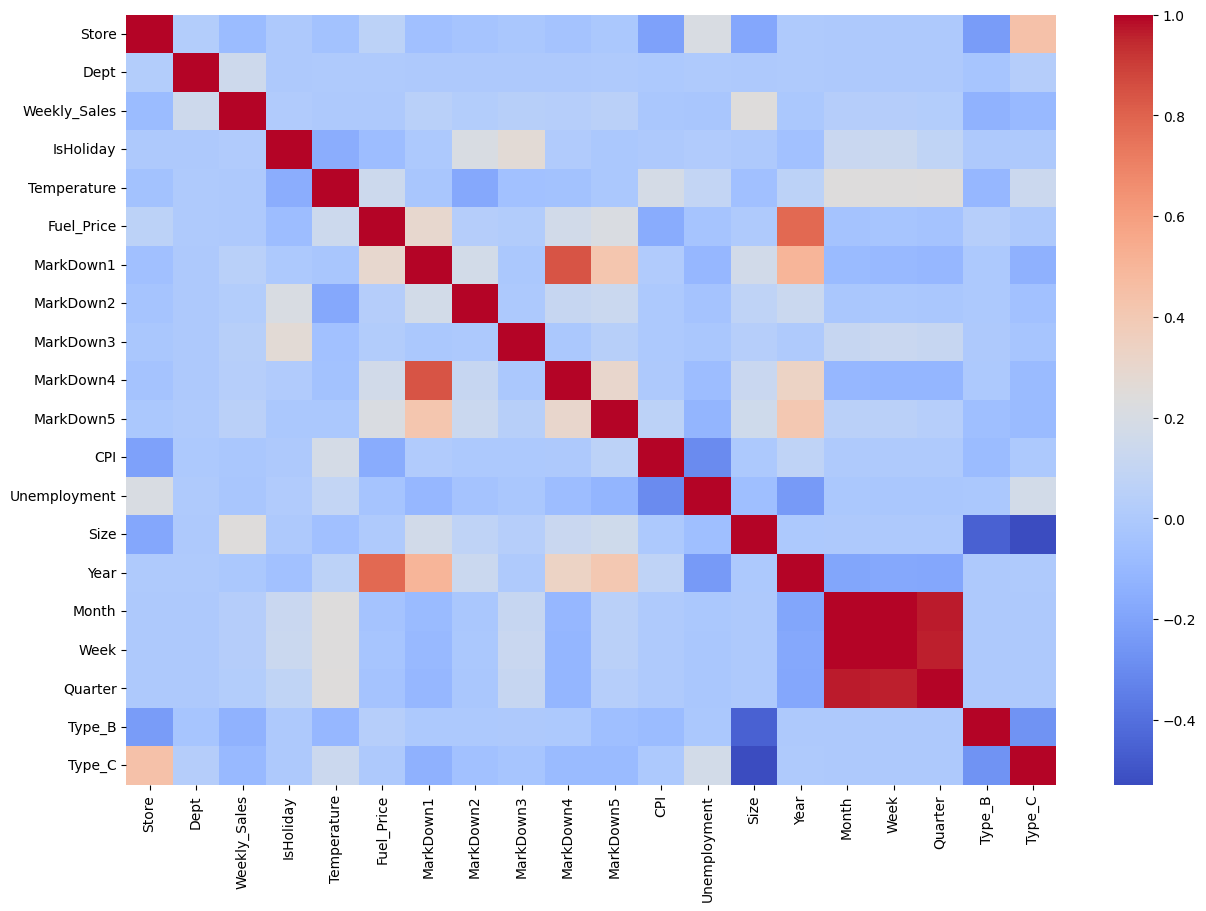

In [ ]:
plt.figure(figsize=(15,10))

sns.heatmap(
    final_data.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.show()

Feature engineering

In [ ]:
final_data["Date"] = pd.to_datetime(final_data["Date"])
final_data["Year"] = final_data["Date"].dt.year
final_data["Month"] = final_data["Date"].dt.month
final_data["Week"] = final_data["Date"].dt.isocalendar().week
final_data["Quarter"] = final_data["Date"].dt.quarter

Feature engineering was performed to capture seasonality and temporal sales patterns hidden within the date variable.

choosing variables

In [ ]:
y = np.log1p(final_data["Weekly_Sales"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
X = final_data.drop(
    ["Weekly_Sales","Date"],
    axis=1
)

y = final_data["Weekly_Sales"]

data splitting

In [ ]:
split_idx = int(len(final_data)*0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

In [ ]:
num_cols = ['Store','Dept','Temperature','Fuel_Price','MarkDown1','MarkDown2', 'MarkDown3','MarkDown4','MarkDown5','CPI','Unemployment','Size', 'Year',
'Month','Week','Quarter']

cat_cols = ['IsHoliday','Type_B','Type_C']

feature scaling

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler,StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num',RobustScaler(),num_cols),
        ('cat','passthrough',cat_cols) ]
)

At the preprocessing stage, multiple machine learning models were planned for comparison, including Linear Regression and other algorithms that are sensitive to feature magnitude. StandardScaler ensures consistent feature scaling and prevents variables with large numerical ranges from dominating model training.

MODEL1

In [ ]:
from sklearn.linear_model import LinearRegression


lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression")
print("MAE :", mean_absolute_error(y_test, lr_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 :", r2_score(y_test, lr_pred))

Linear Regression
MAE : 11908.17904346967
RMSE : 18526.70847591119
R2 : 0.052291245113646356


MODEL2


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(random_state=42)

rf_params = {
    'n_estimators': [100],
    'max_depth': [10],
    'min_samples_split': [2],
    'min_samples_leaf': [2]
}

rf_search = RandomizedSearchCV(
    rf,
    rf_params,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train, y_train)
rf_pred = rf_search.best_estimator_.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE :", rf_mae)
print("RMSE :", rf_rmse)
print("R2 :", rf_r2)

print("\nBest Parameters:")
print(rf_search.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Random Forest Results
MAE : 5332.828901649152
RMSE : 10160.675898185793
R2 : 0.7149483532640141

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10}


Model 3

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor

In [ ]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),

    ('model',XGBRegressor(objective='reg:squarederror',random_state=42))])

param_grid = {'model__n_estimators': [300,500,700],
              'model__max_depth': [4,6,8,10],
              'model__learning_rate': [0.01,0.03,0.05,0.1],
              'model__subsample': [0.8,0.9,1.0],
              'model__colsample_bytree': [0.8,0.9,1.0],'model__min_child_weight': [1,3,5]
}

In [ ]:
search = RandomizedSearchCV(
    pipeline,
    param_grid,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train,y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['Store',
                                                                                'Dept',
                                                                                'Temperature',
                                                                                'Fuel_Price',
                                                                                'MarkDown1',
                                                                                'MarkDown2',
                                                                                'MarkDown3',
                                                                                'MarkDown4',
                                                                                'MarkDown5',
                                                                                'CPI',
                                                                                'Unemployment',
                                                                                'Size',
                                                                                'Year',
                                                                                'Month',
                                                                                'Week',
                                                                                'Quarter']),
                                                                              ('cat',
                                                                               'passthrough',
                                                                               ['IsHoliday',
                                                                                'Type_B',
                                                                                'Type_C'])])),
                                             ('mode...
                                                           num_parallel_tree=None, ...))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.8, 0.9,
                                                                    1.0],
                                        'model__learning_rate': [0.01, 0.03,
                                                                 0.05, 0.1],
                                        'model__max_depth': [4, 6, 8, 10],
                                        'model__min_child_weight': [1, 3, 5],
                                        'model__n_estimators': [300, 500, 700],
                                        'model__subsample': [0.8, 0.9, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

In [ ]:
print(search.best_params_)

{'model__subsample': 0.9, 'model__n_estimators': 700, 'model__min_child_weight': 5, 'model__max_depth': 4, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.9}


In [ ]:
best_model = search.best_estimator_

preds = best_model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test,preds)

rmse = np.sqrt( mean_squared_error(y_test,preds))

r2 = r2_score(y_test,preds)

print("MAE :",mae)
print("RMSE :",rmse)
print("R² :",r2)

MAE : 5857.297291456006
RMSE : 10008.911969453646
R² : 0.7234000507126928


Linear Regression performed poorly because sales forecasting involves complex non-linear relationships among promotions, store characteristics, economic indicators, and seasonal factors. XGBoost effectively captures these interactions through gradient boosting and significantly improved predictive performance.

In [ ]:
feature_names = (
    num_cols +
    cat_cols
)

import pandas as pd

importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance':
    best_model.named_steps[
        'model'
    ].feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
).head(20)

,Feature,Importance
1,Dept,0.251458
17,Type_B,0.221876
11,Size,0.214155
0,Store,0.073605
9,CPI,0.047103
14,Week,0.044102
6,MarkDown3,0.033788
10,Unemployment,0.030240
13,Month,0.019564
18,Type_C,0.011322


Best Model Selection – Comparative Analysis & Justification

Three machine learning models were evaluated for the Walmart Store Sales Forecasting task: Linear Regression, Random Forest Regressor, and XGBoost Regressor.

Model	R² Score
Linear Regression	0.052
Random Forest Regressor	0.710
XGBoost Regressor	0.723


Justification for Final Model Selection

Based on the evaluation results, XGBoost Regressor was selected as the final model because it achieved the highest R² score among all evaluated models. The model demonstrated strong capability in learning complex relationships within the data while maintaining robust generalization performance.

Random Forest also produced competitive results and proved to be an effective forecasting model. However, under the current experimental setup and hyperparameter tuning process, XGBoost delivered the best overall performance and was therefore chosen as the final model for deployment and business interpretation.

Business Interpretation

The selected XGBoost model explains approximately 72.3% of the variation in weekly sales, indicating that store characteristics, promotional activities, economic indicators, and seasonal patterns play a significant role in predicting demand. This level of predictive performance makes the model suitable for supporting inventory planning, promotional strategy, and operational decision-making.
